<a href="https://colab.research.google.com/github/2023giteshpeswani/MLDL-EXPS/blob/main/EXP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0093
Epoch 2/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054
Epoch 3/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039
Epoch 4/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0037
Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0036
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0036
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0036
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0035
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0035
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0034
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


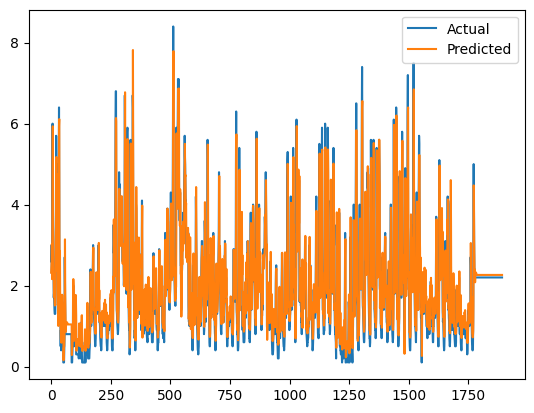

RMSE: 0.6485301185307409


In [ ]:
# Install libraries

!pip install pandas numpy scikit-learn tensorflow matplotlib

# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------

# 1. Load Dataset

# -----------------------------

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

import zipfile, requests
from io import BytesIO

response = requests.get(url)
z = zipfile.ZipFile(BytesIO(response.content))
z.extractall()

df = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')

# -----------------------------

# 2. Data Preprocessing

# -----------------------------

# Remove empty columns

df = df.iloc[:, :-2]

# Replace missing values

df.replace(-200, np.nan, inplace=True)

# Forward fill

df.ffill(inplace=True)

# 🔥 FIX: Convert time format properly

df['Time'] = df['Time'].str.replace('.', ':', regex=False)

# Combine date + time correctly

df['Datetime'] = pd.to_datetime(
df['Date'] + ' ' + df['Time'],
format='%d/%m/%Y %H:%M:%S'
)

df.set_index('Datetime', inplace=True)

# Select feature

data = df[['CO(GT)']].values

# Normalize

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -----------------------------

# 3. Create Dataset (FIXED INDENTATION)

# -----------------------------

def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(data_scaled, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

# -----------------------------

# 4. Train-Test Split

# -----------------------------

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------

# 5. LSTM Model

# -----------------------------

model = Sequential()
model.add(LSTM(50, input_shape=(time_step, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# -----------------------------

# 6. Train

# -----------------------------

model.fit(X_train, y_train, epochs=10, batch_size=32)

# -----------------------------

# 7. Prediction

# -----------------------------

y_pred = model.predict(X_test)

# Reverse scaling

y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# -----------------------------

# 8. Plot

# -----------------------------

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

# -----------------------------

# 9. RMSE

# -----------------------------

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print("RMSE:", rmse)
